In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, validation_curve
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('2_preprocessed_encoded.csv')

<Axes: title={'center': 'Target Class Distribution'}, xlabel='target'>

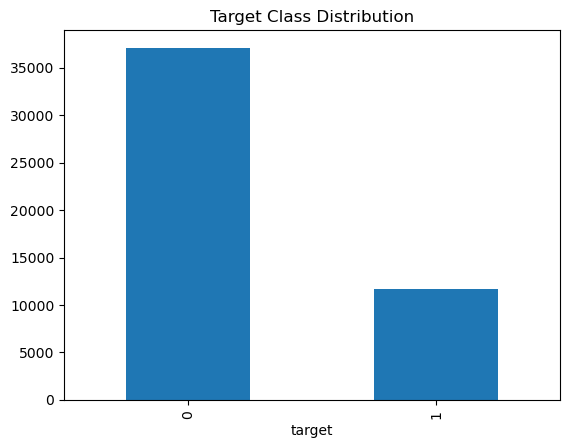

In [3]:
df['target'].value_counts().plot(kind='bar', title='Target Class Distribution')

In [4]:
df.shape

(48790, 22)

In [5]:
X = df.drop(columns=['target'])
y = df['target']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [7]:
df.shape

(48790, 22)

In [8]:
# 3️⃣ SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [9]:
X_train_resampled.shape, y_train_resampled.shape

((59374, 21), (59374,))

In [10]:
X_test.shape, y_test.shape

((9758, 21), (9758,))

In [11]:
# 4️⃣ Feature scaling (after SMOTE)
scaler = StandardScaler()
X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

In [13]:
# 5️⃣ Initial SVM + 10-fold cross-validation
svm = SVC(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
cv_scores = cross_val_score(svm, X_train_resampled_scaled, y_train_resampled, cv=cv, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

In [ ]:
# 6️⃣ Hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}
grid = GridSearchCV(SVC(probability=True, random_state=42), param_grid, cv=cv, scoring='accuracy')
grid.fit(X_train_resampled_scaled, y_train_resampled)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

In [ ]:
df.shape

In [ ]:
# 8️⃣ Train final model on entire resampled training data
# best_svm = grid.best_estimator_
svm.fit(X_train_resampled_scaled, y_train_resampled)

# 9️⃣ Evaluate on test set
y_pred = svm.predict(X_test_scaled)
y_proba = svm.predict_proba(X_test_scaled)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

In [ ]:
# 10️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix (SVM)")
plt.show()

In [ ]:
# 🔟 ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (SVM)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
#classification_report
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred, target_names=['<=50k', '>50k'])
print("Classification Report:\n", report)